# Analiza aluminijastih sistemov

V tej analizi primerjam tehnične lastnosti aluminijastih drsnih sistemov različnih proizvajalcev. Podatki so bili pridobljeni z uradnih spletnih strani proizvajalcev Reynaers, AluK in Cortizo ter nato s pomočjo programa v Pythonu izluščeni iz HTML datotek in shranjeni v CSV datoteko.

Analiza vključuje primerjavo toplotne prehodnosti, največjih dovoljenih dimenzij, nosilnosti, globine okvirja, največje debeline stekla ter razredov zrakotesnosti. Namen analize je ugotoviti, kako se posamezni sistemi med seboj razlikujejo ter kateri proizvajalci v povprečju ponujajo boljše rezultate pri posameznih tehničnih lastnostih.

Za obdelavo in prikaz podatkov uporabljam knjižnico pandas, rezultati pa so prikazani s tabelami in različnimi grafi.

## Pregled podatkov

In [2]:
import pandas as pd

SISTEMI = pd.read_csv("podatki/sistemi.csv")

SISTEMI

,proizvajalec,sistem,toplotna_prehodnost,max_visina_mm,max_sirina_mm,max_teza_kg,globina_okvirja_mm,najvecja_debelina_stekla_mm,zrakotesnost,vodotesnost,odpornost_na_veter
0,AluK,infinium,1.3,3300,3000,400.0,NaN,38,Class 4,Class 8A,Class C3
1,AluK,sc140tt,"1,7",2800,2500,400.0,NaN,40,Class 4,Class 8A,Class A4
2,AluK,sc156,1.4,3100,2700,300.0,NaN,28,Class 4,Class E1500,Class B5
3,Cortizo,4600plus,0.65,3500,3300,400.0,NaN,65,Class 4,Class E750,Class C5
4,Cortizo,4700,1.0,3000,2500,280.0,NaN,36,Class 3,Class 7A,Class C5
5,Cortizo,corvision,1.3,3000,2500,320.0,NaN,30,Class 4,Class 7A,Class C5
6,Cortizo,corvisionevolution,0.88,3500,3500,500.0,NaN,44,Class 4,Class E900,Class C5
7,Reynaers,conceptpatio130,1.4,2700,2700,300.0,139.0,45,Class 4,Class E750,Class B5
8,Reynaers,conceptpatio155,0.99,3500,2700,NaN,155.0,52,Class 4,Class E900,Class C4
9,Reynaers,conceptpatio68,1.4,2800,1500,200.0,68.0,38,Class 4,Class 7B,Class C4


Tabela prikazuje vse analizirane aluminijaste drsne sisteme ter njihove tehnične lastnosti. Za vsak sistem so prikazani proizvajalec, toplotna prehodnost, največje dovoljene dimenzije, nosilnost, globina okvirja, največja debelina stekla ter razredi zrakotesnosti, vodotesnosti in odpornosti na veter. Posamezna vrstica predstavlja en aluminijasti drsni sistem, stolpci pa njegove tehnične lastnosti. Na podlagi teh podatkov bom v nadaljevanju primerjala sisteme med seboj ter analizirala razlike med proizvajalci.

In [ ]:
SISTEMI.head()

In [ ]:
SISTEMI.shape

In [ ]:
SISTEMI.info()

In [ ]:
SISTEMI.isna().sum()

In [4]:
SISTEMI["toplotna_prehodnost"] = (SISTEMI["toplotna_prehodnost"].str.replace(",", ".", regex=False).astype(float))

In [5]:
SISTEMI.dtypes

proizvajalec                       str
sistem                             str
toplotna_prehodnost            float64
max_visina_mm                    int64
max_sirina_mm                    int64
max_teza_kg                    float64
globina_okvirja_mm             float64
najvecja_debelina_stekla_mm      int64
zrakotesnost                       str
vodotesnost                        str
odpornost_na_veter                 str
dtype: object

## Grafični prikaz podatkov

### Toplotna izolacija

In [9]:
SISTEMI.sort_values("toplotna_prehodnost").head()
#sistemi z najnižjo toplotno prehodnostjo

,proizvajalec,sistem,toplotna_prehodnost,max_visina_mm,max_sirina_mm,max_teza_kg,globina_okvirja_mm,najvecja_debelina_stekla_mm,zrakotesnost,vodotesnost,odpornost_na_veter
3,Cortizo,4600plus,0.65,3500,3300,400.0,NaN,65,Class 4,Class E750,Class C5
11,Reynaers,masterpatio,0.80,3600,3600,600.0,180.0,62,Class 4,Class E1200,Class C5
10,Reynaers,hifinity,0.80,4000,3500,750.0,148.0,54,Class 4,Class E750,Class C5
6,Cortizo,corvisionevolution,0.88,3500,3500,500.0,NaN,44,Class 4,Class E900,Class C5
8,Reynaers,conceptpatio155,0.99,3500,2700,NaN,155.0,52,Class 4,Class E900,Class C4


Tabela prikazuje pet sistemov z najnižjo toplotno prehodnostjo. Nižja vrednost Uw pomeni boljšo toplotno izolativnost.

In [7]:
SISTEMI.groupby("proizvajalec")["toplotna_prehodnost"].mean()
#popvrečna toplotna prehodnost za vsakega proizvajalca

proizvajalec
AluK        1.466667
Cortizo     0.957500
Reynaers    1.131667
Name: toplotna_prehodnost, dtype: float64

<Axes: title={'center': 'Povprečna toplotna prehodnost po proizvajalcu'}, xlabel='proizvajalec'>

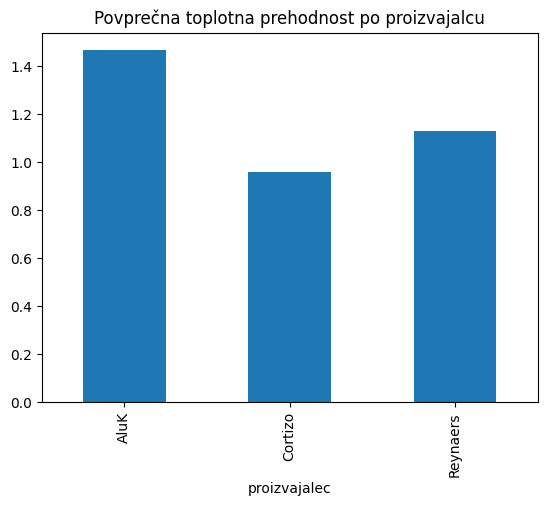

In [8]:
SISTEMI.groupby("proizvajalec")["toplotna_prehodnost"].mean().plot(kind="bar",title="Povprečna toplotna prehodnost po proizvajalcu")

Graf prikazuje povprečno toplotno prehodnost sistemov posameznega proizvajalca. Primerjava omogoča pregled razlik v povprečni toplotni izolativnosti med proizvajalci.

<Axes: title={'center': 'Toplotna prehodnost drsnih sistemov'}, xlabel='sistem'>

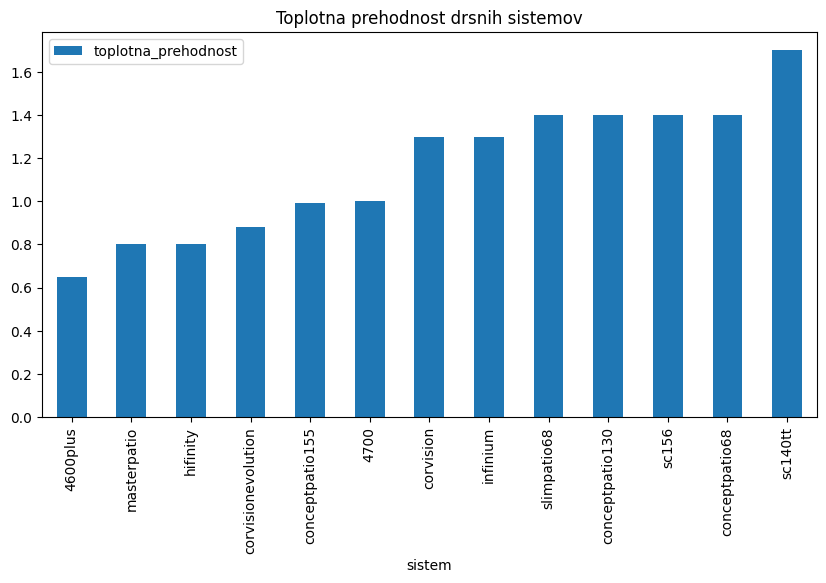

In [13]:

SISTEMI.sort_values("toplotna_prehodnost").plot(
    x="sistem",
    y="toplotna_prehodnost",
    kind="bar",
    figsize=(10, 5),
    title="Toplotna prehodnost drsnih sistemov")

# Prikaže toplotno prehodnost posameznih sistemov.

Graf prikazuje toplotno prehodnost Uw posameznih aluminijastih drsnih sistemov. Nižja vrednost Uw pomeni boljšo toplotno izolativnost sistema. Med analiziranimi sistemi lahko opazimo precejšnje razlike v vrednostih toplotne prehodnosti.

<Axes: title={'center': 'Delež razredov zrakotesnosti'}>

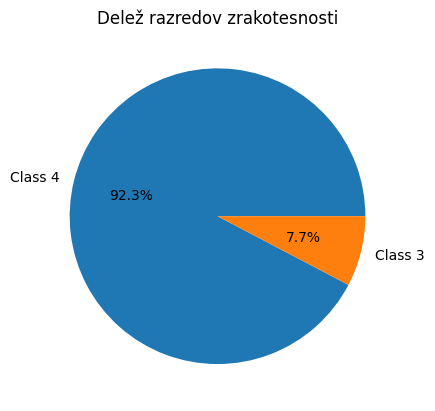

In [26]:
# Prikaže delež posameznih razredov zrakotesnosti.
SISTEMI["zrakotesnost"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ylabel="",
    title="Delež razredov zrakotesnosti")

Tortni diagram prikazuje deleže posameznih razredov zrakotesnosti v analiziranem naboru sistemov. Večina analiziranih sistemov dosega razred zrakotesnosti Class 4, manjši delež pa Class 3. V analiziranem naboru 92,3 % sistemov dosega razred zrakotesnosti Class 4, medtem ko 7,7 % sistemov dosega razred Class 3.

### Dimenzijske lastnosti in nosilnost

In [10]:

SISTEMI.sort_values("max_visina_mm", ascending=False).head()
# sistemi z največjo dovoljeno višino.

,proizvajalec,sistem,toplotna_prehodnost,max_visina_mm,max_sirina_mm,max_teza_kg,globina_okvirja_mm,najvecja_debelina_stekla_mm,zrakotesnost,vodotesnost,odpornost_na_veter
10,Reynaers,hifinity,0.80,4000,3500,750.0,148.0,54,Class 4,Class E750,Class C5
11,Reynaers,masterpatio,0.80,3600,3600,600.0,180.0,62,Class 4,Class E1200,Class C5
6,Cortizo,corvisionevolution,0.88,3500,3500,500.0,NaN,44,Class 4,Class E900,Class C5
8,Reynaers,conceptpatio155,0.99,3500,2700,NaN,155.0,52,Class 4,Class E900,Class C4
3,Cortizo,4600plus,0.65,3500,3300,400.0,NaN,65,Class 4,Class E750,Class C5


V grafu je 5 sistemov z največjo dovoljeno višino

<Axes: title={'center': 'Največja višina drsnih sistemov'}, xlabel='sistem'>

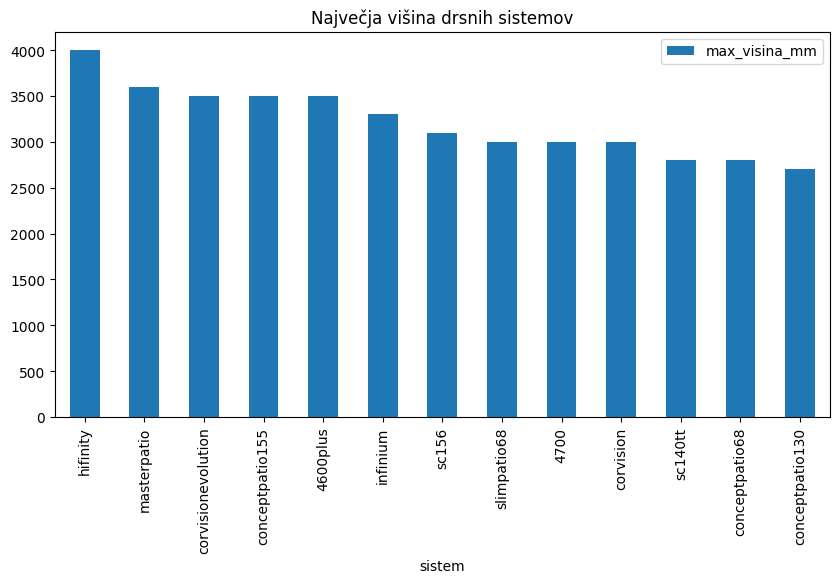

In [14]:
# Primerja največjo dovoljeno višino posameznih sistemov.
SISTEMI.sort_values("max_visina_mm", ascending=False).plot(
    x="sistem",
    y="max_visina_mm",
    kind="bar",
    figsize=(10, 5),
    title="Največja višina drsnih sistemov")

Graf prikazuje največjo dovoljeno višino posameznega sistema. Med sistemi so opazne razlike v največjih možnih dimenzijah drsnih elementov.

In [11]:

SISTEMI.sort_values("max_sirina_mm", ascending=False).head()
# sistemi z največjo dovoljeno širino.

,proizvajalec,sistem,toplotna_prehodnost,max_visina_mm,max_sirina_mm,max_teza_kg,globina_okvirja_mm,najvecja_debelina_stekla_mm,zrakotesnost,vodotesnost,odpornost_na_veter
11,Reynaers,masterpatio,0.80,3600,3600,600.0,180.0,62,Class 4,Class E1200,Class C5
6,Cortizo,corvisionevolution,0.88,3500,3500,500.0,NaN,44,Class 4,Class E900,Class C5
10,Reynaers,hifinity,0.80,4000,3500,750.0,148.0,54,Class 4,Class E750,Class C5
3,Cortizo,4600plus,0.65,3500,3300,400.0,NaN,65,Class 4,Class E750,Class C5
0,AluK,infinium,1.30,3300,3000,400.0,NaN,38,Class 4,Class 8A,Class C3


V tabeli je 5 sistemov z največjo dovoljeno širino

<Axes: title={'center': 'Največja višina in širina sistemov'}, xlabel='sistem'>

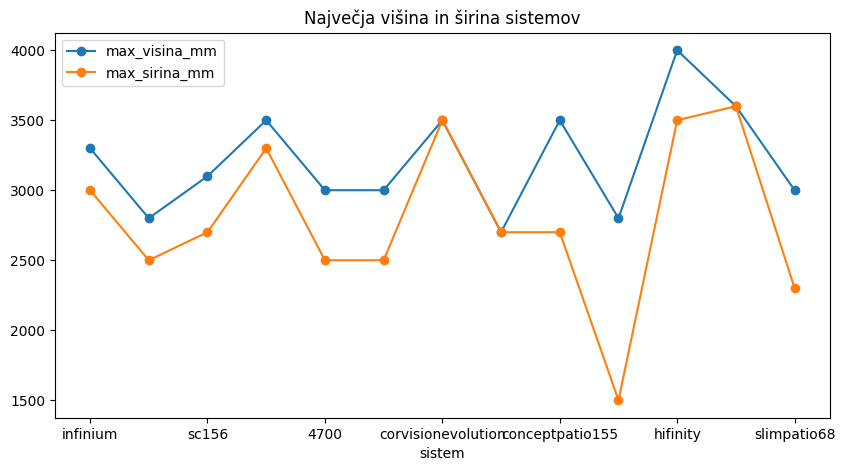

In [20]:
# Primerja največjo višino in širino posameznih sistemov na istem črtnem grafu.
SISTEMI.plot(
    x="sistem",
    y=["max_visina_mm", "max_sirina_mm"],
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Največja višina in širina sistemov")

Črtni graf hkrati prikazuje največjo dovoljeno višino in širino posameznih sistemov. Omogoča neposredno primerjavo največjih dimenzij in pokaže, kateri sistemi so primerni za večje drsne elemente.

In [ ]:

SISTEMI["najvecja_povrsina_m2"] = (SISTEMI["max_visina_mm"] * SISTEMI["max_sirina_mm"] / 1_000_000)

SISTEMI[["proizvajalec", "sistem", "najvecja_povrsina_m2"]]

# Izračuna največjo možno površino sistema v kvadratnih metrih

,proizvajalec,sistem,najvecja_povrsina_m2
0,AluK,infinium,9.90
1,AluK,sc140tt,7.00
2,AluK,sc156,8.37
3,Cortizo,4600plus,11.55
4,Cortizo,4700,7.50
5,Cortizo,corvision,7.50
6,Cortizo,corvisionevolution,12.25
7,Reynaers,conceptpatio130,7.29
8,Reynaers,conceptpatio155,9.45
9,Reynaers,conceptpatio68,4.20


Tabela prikazuje največjo izračunano površino posameznega drsnega sistema. Površina je izračunana iz največje dovoljene višine in širine posameznega sistema.

<Axes: title={'center': 'Največja dovoljena teža drsnih sistemov'}, xlabel='sistem'>

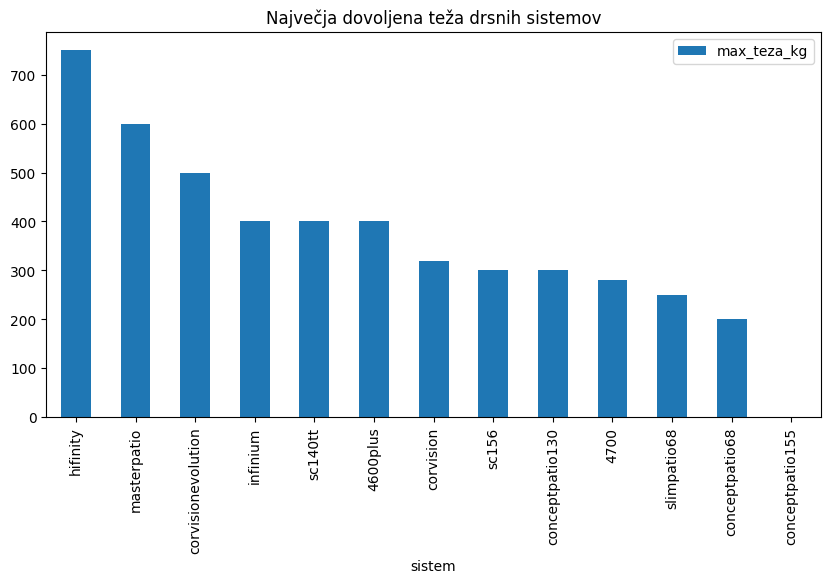

In [15]:
# Primerja največjo dovoljeno težo posameznih drsnih sistemov.
SISTEMI.sort_values("max_teza_kg", ascending=False).plot(
    x="sistem",
    y="max_teza_kg",
    kind="bar",
    figsize=(10, 5),
    title="Največja dovoljena teža drsnih sistemov")

Graf prikazuje največjo dovoljeno težo krila oziroma elementa pri posameznem sistemu. Večja dovoljena teža omogoča uporabo večjih in težjih zasteklitev.

<Axes: title={'center': 'Povprečna največja dovoljena teža po proizvajalcu'}, xlabel='proizvajalec'>

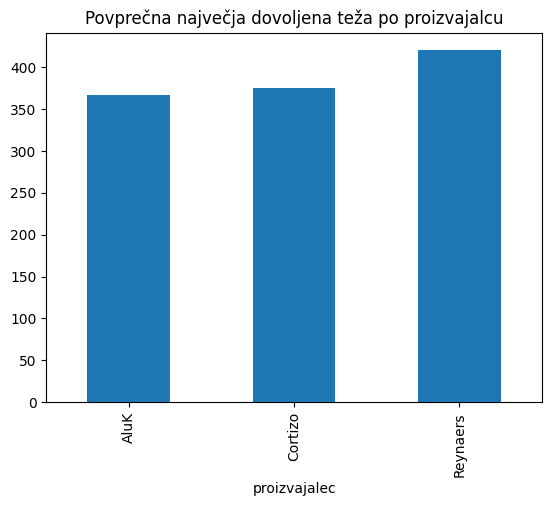

In [25]:
# Izračuna in prikaže povprečno največjo dovoljeno težo po proizvajalcih.
SISTEMI.groupby("proizvajalec")["max_teza_kg"].mean().plot(
    kind="bar",
    title="Povprečna največja dovoljena teža po proizvajalcu")

<Axes: title={'center': 'Primerjava povprečnih dimenzij in nosilnosti po proizvajalcu'}, xlabel='proizvajalec'>

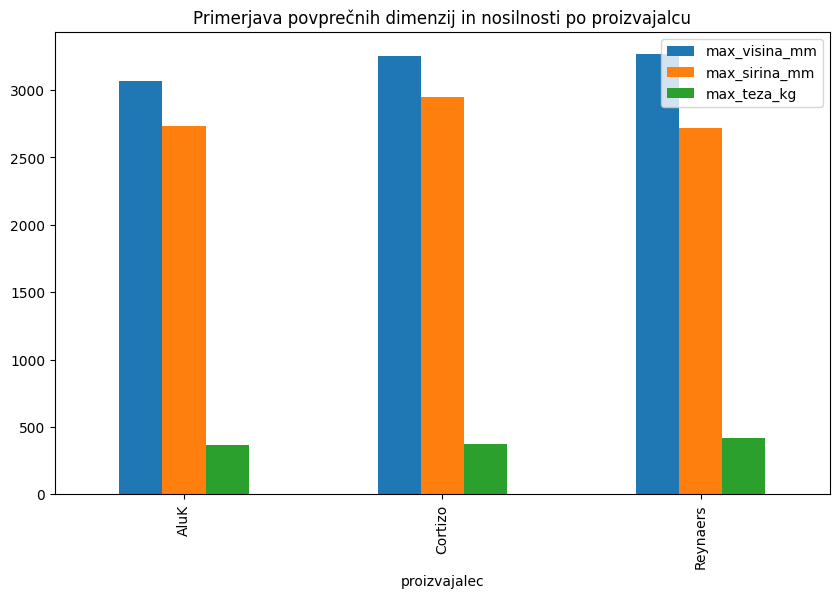

In [22]:
# Primerja povprečno višino, širino in dovoljeno težo po proizvajalcih.

SISTEMI.groupby("proizvajalec")[
    ["max_visina_mm", "max_sirina_mm", "max_teza_kg"]
].mean().plot(
    kind="bar",
    figsize=(10, 6),
    title="Primerjava povprečnih dimenzij in nosilnosti po proizvajalcu")

Graf primerja povprečno največjo višino, največjo širino in največjo dovoljeno težo sistemov posameznega proizvajalca. Iz grafa je razvidno, da se proizvajalci razlikujejo predvsem po dimenzijah in nosilnosti sistemov, pri čemer imajo nekateri v povprečju večje dovoljene mere in večjo nosilnost.

<Axes: title={'center': 'Največja dovoljena debelina stekla'}, xlabel='sistem'>

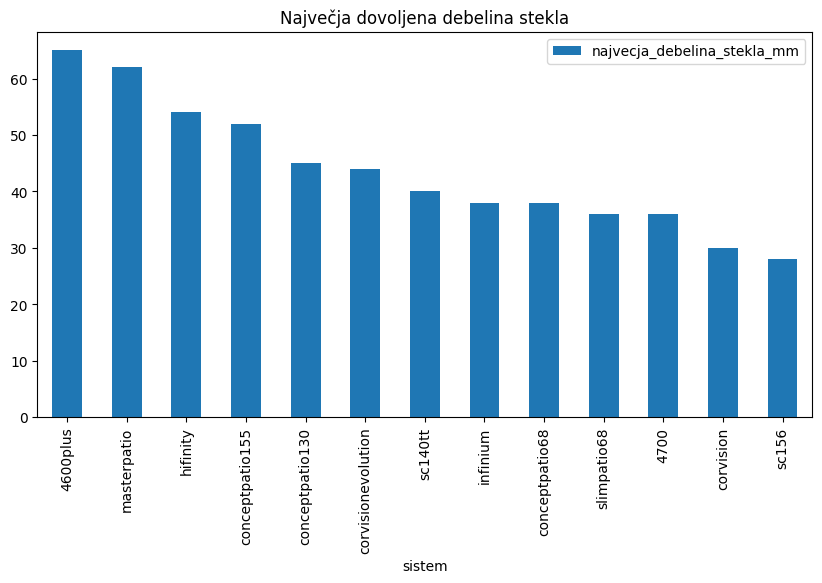

In [16]:
# Primerja največjo dovoljeno debelino stekla med sistemi.
SISTEMI.sort_values("najvecja_debelina_stekla_mm", ascending=False).plot(
    x="sistem",
    y="najvecja_debelina_stekla_mm",
    kind="bar",
    figsize=(10, 5),
    title="Največja dovoljena debelina stekla")

Graf primerja največjo dovoljeno debelino stekla pri posameznih sistemih. Sistemi, ki omogočajo večjo debelino stekla, dopuščajo uporabo debelejših oziroma večslojnih zasteklitev.

### Povezave med lastnosmi

<Axes: title={'center': 'Globina okvirja in toplotna prehodnost'}, xlabel='globina_okvirja_mm', ylabel='toplotna_prehodnost'>

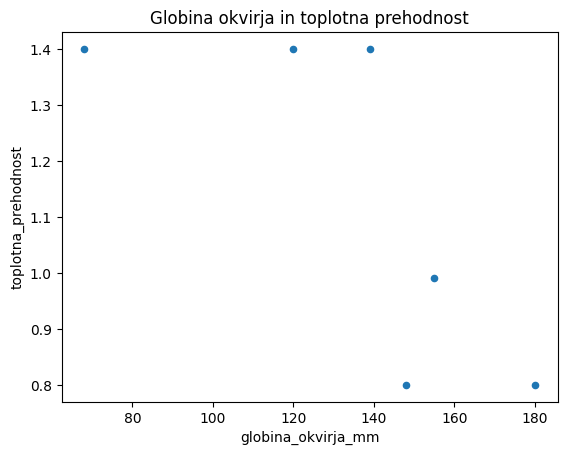

In [17]:
# Prikaže povezavo med globino okvirja in toplotno prehodnostjo.
SISTEMI.plot(
    x="globina_okvirja_mm",
    y="toplotna_prehodnost",
    kind="scatter",
    title="Globina okvirja in toplotna prehodnost")

Raztreseni graf prikazuje razmerje med globino okvirja in toplotno prehodnostjo. Z njim lahko preverimo, ali se pri sistemih z večjo globino okvirja pojavljajo nižje vrednosti toplotne prehodnosti.

<Axes: title={'center': 'Debelina stekla in največja dovoljena teža'}, xlabel='najvecja_debelina_stekla_mm', ylabel='max_teza_kg'>

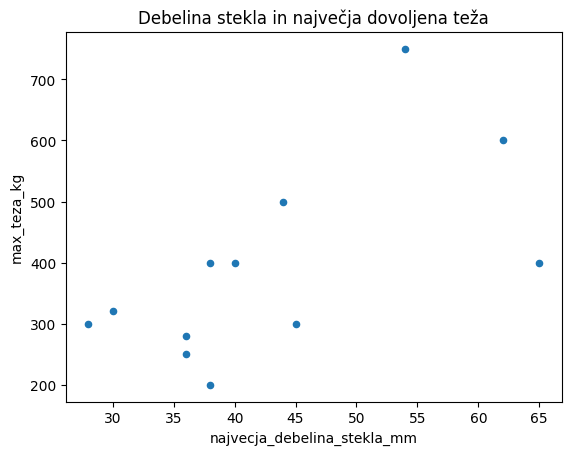

In [18]:
# Prikaže povezavo med dovoljeno težo sistema in največjo debelino stekla.
SISTEMI.plot(
    x="najvecja_debelina_stekla_mm",
    y="max_teza_kg",
    kind="scatter",
    title="Debelina stekla in največja dovoljena teža")

Graf prikazuje povezavo med največjo dovoljeno debelino stekla in največjo dovoljeno težo sistema. Na ta način lahko primerjamo, ali sistemi, ki omogočajo debelejše zasteklitve, praviloma omogočajo tudi večje obremenitve.

## Statistični pregled podatkov

In [23]:
# Prikaže osnovne statistične podatke številskih stolpcev.
SISTEMI.describe()

,toplotna_prehodnost,max_visina_mm,max_sirina_mm,max_teza_kg,globina_okvirja_mm,najvecja_debelina_stekla_mm,najvecja_povrsina_m2
count,13.000000,13.000000,13.000000,12.000000,6.000000,13.000000,13.000000
mean,1.155385,3215.384615,2792.307692,391.666667,135.000000,43.692308,9.143846
std,0.317952,384.807644,588.021454,158.104300,38.272706,11.535341,2.854253
min,0.650000,2700.000000,1500.000000,200.000000,68.000000,28.000000,4.200000
25%,0.880000,3000.000000,2500.000000,295.000000,124.750000,36.000000,7.290000
50%,1.300000,3100.000000,2700.000000,360.000000,143.500000,40.000000,8.370000
75%,1.400000,3500.000000,3300.000000,425.000000,153.250000,52.000000,11.550000
max,1.700000,4000.000000,3600.000000,750.000000,180.000000,65.000000,14.000000


Tabela prikazuje osnovne opisne statistike številskih podatkov, kot so število vrednosti, povprečje, standardni odklon, najmanjša in največja vrednost ter kvartili. Tako lahko dobimo splošen pregled razpona in porazdelitve tehničnih lastnosti analiziranih sistemov.

In [24]:
# Izračuna povprečne vrednosti tehničnih lastnosti po proizvajalcih.
SISTEMI.groupby("proizvajalec")[
    [
        "toplotna_prehodnost",
        "max_visina_mm",
        "max_sirina_mm",
        "max_teza_kg",
        "globina_okvirja_mm",
        "najvecja_debelina_stekla_mm"
    ]
].mean()

,toplotna_prehodnost,max_visina_mm,max_sirina_mm,max_teza_kg,globina_okvirja_mm,najvecja_debelina_stekla_mm
proizvajalec,,,,,,
AluK,1.466667,3066.666667,2733.333333,366.666667,NaN,35.333333
Cortizo,0.957500,3250.000000,2950.000000,375.000000,NaN,43.750000
Reynaers,1.131667,3266.666667,2716.666667,420.000000,135.0,47.833333


Tabela prikazuje povprečne vrednosti izbranih tehničnih lastnosti za posameznega proizvajalca. Tako lahko med seboj primerjamo povprečne karakteristike sistemov proizvajalcev AluK, Cortizo in Reynaers.

## Zaključek

Na podlagi analize lahko ugotovim, da se aluminijasti drsni sistemi različnih proizvajalcev precej razlikujejo glede toplotne prehodnosti, največjih dimenzij, nosilnosti in ostalih tehničnih lastnosti.

Pri toplotni prehodnosti imajo nekateri sistemi izrazito nižje vrednosti, kar pomeni boljšo toplotno izolativnost. Med analiziranimi sistemi izstopajo predvsem določeni sistemi proizvajalcev Cortizo in Reynaers, ki dosegajo nižje vrednosti v primerjavi z ostalimi sistemi.

Pri največjih dovoljenih dimenzijah so razlike med sistemi prav tako precejšnje. Nekateri sistemi omogočajo bistveno večje višine in širine, kar je pomembno pri načrtovanju večjih steklenih in panoramskih odprtin. Pri tem so sistemi proizvajalca Reynaers v povprečju dosegali večje višine, medtem ko so sistemi Cortizo pri nekaterih primerjavah dosegali večje povprečne širine.

Tudi pri nosilnosti so opazne razlike. Sistemi z večjo dovoljeno težo omogočajo uporabo težjih in večjih steklenih elementov. V tej primerjavi so nekateri Reynaersovi sistemi dosegali zelo visoke dovoljene obremenitve.

Pri zrakotesnosti je večina analiziranih sistemov dosegala razred Class 4, kar kaže na dobro zrakotesnost večine sistemov v izbranem naboru. Pri vodotesnosti in odpornosti na veter so bile razlike nekoliko večje, saj proizvajalci ponujajo sisteme z različnimi razredi glede na namen uporabe.

Iz analize lahko sklepamo, da ni enega sistema, ki bi bil najboljši po vseh kriterijih hkrati. Nekateri sistemi imajo boljšo toplotno izolativnost, drugi omogočajo večje dimenzije ali večjo nosilnost. Izbira primernega drsnega sistema je zato odvisna od zahtev posameznega objekta in od tega, katere tehnične lastnosti so pri projektu najpomembnejše.

Analiza je pokazala, da je mogoče podatke različnih proizvajalcev uspešno primerjati, čeprav niso vse tehnične lastnosti na spletnih straneh zapisane na popolnoma enak način. Zaradi tega je bilo treba pri izluščanju podatkov upoštevati različne zapise in oznake posameznih proizvajalcev.